In [1]:
import math
import os
from pathlib import Path

import numpy as np
import pandas as pd

DIR = Path(".")
ALPHA = 0.05
RANDOM_SEED = 42


TEST_SIZE = 0.5

os.makedirs("tables", exist_ok=True)
os.makedirs("images", exist_ok=True)


_df = pd.read_csv("diabetes.csv")
Y_NAME = "Glucose"
DROP = {"Outcome", "Insulin"}
X_NAMES = [c for c in _df.columns if c not in DROP and c != Y_NAME]

n_before = len(_df)
n_y_zero = int((_df[Y_NAME] == 0).sum())
_df = _df.loc[_df[Y_NAME] > 0].reset_index(drop=True)
print(
    f"Удалено строк с {Y_NAME}=0 (биологически невозможно, пропуск измерения): "
    f"{n_y_zero} (было {n_before}, осталось {len(_df)})"
)

Y = _df[Y_NAME].astype(float)
X = _df[X_NAMES].astype(float)

print("Y =", Y_NAME)
print("X columns (after dropping Outcome, Insulin):", X_NAMES)
print("n =", len(_df))

Удалено строк с Glucose=0 (биологически невозможно, пропуск измерения): 5 (было 768, осталось 763)
Y = Glucose
X columns (after dropping Outcome, Insulin): ['Pregnancies', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age']
n = 763


In [2]:
ZERO_AS_MISSING = {"BloodPressure", "SkinThickness", "BMI"}

zero_counts = (X == 0).sum().sort_values(ascending=False)
print("Zero counts in columns:")
display(pd.DataFrame({"zeros": zero_counts}))
print("ZERO_AS_MISSING used:", sorted(ZERO_AS_MISSING))


def quantile_outlier_summary(df: pd.DataFrame, ratio_lo=0.5, ratio_hi=2.0):
    rows = []
    for c in df.columns:
        s = df[c].astype(float).copy()
        
        if c in ZERO_AS_MISSING:
            s = s.replace(0, np.nan)
        s = s.dropna()
        q1 = float(np.quantile(s, 0.25))
        q2 = float(np.quantile(s, 0.50))
        q3 = float(np.quantile(s, 0.75))
        dL = q2 - q1
        dR = q3 - q2
        iqr = q3 - q1
        ratio = float(dR / dL) if dL != 0 else float("inf")
        flag = (ratio < ratio_lo) or (ratio > ratio_hi)
        rows.append(
            {
                "feature": c,
                "Q1": q1,
                "Q2(median)": q2,
                "Q3": q3,
                "dL=Q2-Q1": dL,
                "dR=Q3-Q2": dR,
                "ratio=dR/dL": ratio,
                "IQR": iqr,
                "asymmetry_flag": flag,
            }
        )
    return pd.DataFrame(rows).sort_values("asymmetry_flag", ascending=False)

outlier_tbl = quantile_outlier_summary(X)
display(outlier_tbl)

n_flag = int(outlier_tbl["asymmetry_flag"].sum())
print(f"Asymmetry flags: {n_flag} / {len(outlier_tbl)} features")

IQR_MAX = {}  
if IQR_MAX:
    outlier_tbl["IQR_max"] = outlier_tbl["feature"].map(IQR_MAX)
    outlier_tbl["IQR_exceeds"] = outlier_tbl.apply(
        lambda r: (r["IQR"] > r["IQR_max"]) if pd.notna(r["IQR_max"]) else False,
        axis=1,
    )
    display(outlier_tbl[["feature", "IQR", "IQR_max", "IQR_exceeds"]])
else:
    print("IQR_MAX not set.")

Zero counts in columns:


,zeros
SkinThickness,227
Pregnancies,111
BloodPressure,35
BMI,11
DiabetesPedigreeFunction,0
Age,0


ZERO_AS_MISSING used: ['BMI', 'BloodPressure', 'SkinThickness']


,feature,Q1,Q2(median),Q3,dL=Q2-Q1,dR=Q3-Q2,ratio=dR/dL,IQR,asymmetry_flag
5,Age,24.0000,29.000,41.0000,5.0000,12.0000,2.400000,17.000,True
0,Pregnancies,1.0000,3.000,6.0000,2.0000,3.0000,1.500000,5.000,False
1,BloodPressure,64.0000,72.000,80.0000,8.0000,8.0000,1.000000,16.000,False
2,SkinThickness,22.0000,29.000,36.0000,7.0000,7.0000,1.000000,14.000,False
3,BMI,27.5000,32.300,36.6000,4.8000,4.3000,0.895833,9.100,False
4,DiabetesPedigreeFunction,0.2435,0.374,0.6265,0.1305,0.2525,1.934866,0.383,False


Asymmetry flags: 1 / 6 features
IQR_MAX not set.


In [3]:
rho_y = X.corrwith(Y, method="spearman")
n = len(Y)
K = n - 2  # число степеней свободы
rho_vals = rho_y.to_numpy(float)

# t-статистика значимости
t_calc = rho_vals * np.sqrt(K / np.maximum(1e-12, 1.0 - rho_vals**2))

try:
    from scipy.stats import t as student_t

    t_crit = float(student_t.ppf(1 - ALPHA / 2, K))
except Exception:
    t_crit = 1.959964

# Критическая точка по |rho_S| через t_crit:
# rho_crit = t_crit / sqrt(t_crit^2 + K)
rho_crit = float(t_crit / np.sqrt(t_crit**2 + K))

spearman_signif = pd.DataFrame(
    {
        "Xj": rho_y.index,
        "rho_S": rho_vals,
        "n": n,
        "K": K,
        "alpha": ALPHA,
        "t_crit": t_crit,
        "t_calc": t_calc,
        "rho_crit": rho_crit,
        "decision": [
            "reject H0" if abs(r) >= rho_crit else "fail to reject H0" for r in rho_vals
        ],
    }
).sort_values("rho_S", key=lambda s: s.abs(), ascending=False)

spearman_signif

,Xj,rho_S,n,K,alpha,t_crit,t_calc,rho_crit,decision
5,Age,0.283315,763,761,0.05,1.963086,8.149489,0.070982,reject H0
1,BloodPressure,0.235408,763,761,0.05,1.963086,6.681810,0.070982,reject H0
3,BMI,0.235315,763,761,0.05,1.963086,6.678998,0.070982,reject H0
0,Pregnancies,0.129547,763,761,0.05,1.963086,3.604094,0.070982,reject H0
4,DiabetesPedigreeFunction,0.090596,763,761,0.05,1.963086,2.509528,0.070982,reject H0
2,SkinThickness,0.067173,763,761,0.05,1.963086,1.857254,0.070982,fail to reject H0


In [4]:
spearman_signif.to_csv("tables/lab4_spearman_yx_significance.csv", index=False, encoding="utf-8-sig")
try:
    spearman_signif_round = spearman_signif.copy()
    for c in ["rho_S", "t_calc", "t_crit", "rho_crit"]:
        spearman_signif_round[c] = spearman_signif_round[c].astype(float).round(6)
    spearman_signif_round = spearman_signif_round.rename(
        columns={
            "rho_S": "$\\rho_S$",
            "t_crit": "$t_{crit}$",
            "t_calc": "$t_{calc}$",
            "rho_crit": "$\\rho_{crit}$",
            "alpha": "$\\alpha$",
            "K": "$K$",
        }
    )
    spearman_signif_round.to_latex(
        "tables/lab4_spearman_yx_significance.tex",
        index=False,
        escape=False,
    )
except Exception as e:
    print("LaTeX export failed:", repr(e))

print("Saved tables/lab4_spearman_yx_significance.csv and .tex")

Saved tables/lab4_spearman_yx_significance.csv and .tex


In [5]:
def train_test_split_idx(n: int, test_size: float, seed: int):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    m = int(round(n * test_size))
    test = np.sort(idx[:m])
    train = np.sort(idx[m:])
    return train, test

def median_impute_fit(Xm: np.ndarray):
    med = np.nanmedian(Xm, axis=0)
    return med

def median_impute_apply(Xm: np.ndarray, med: np.ndarray):
    Xm2 = Xm.copy()
    mask = ~np.isfinite(Xm2)
    if np.any(mask):
        Xm2[mask] = np.take(med, np.where(mask)[1])
    return Xm2

def iqr_clip_fit(Xm: np.ndarray, k: float = 1.5):
    q1 = np.quantile(Xm, 0.25, axis=0)
    q3 = np.quantile(Xm, 0.75, axis=0)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return lo, hi

def iqr_clip_apply(Xm: np.ndarray, lo: np.ndarray, hi: np.ndarray):
    return np.clip(Xm, lo, hi)

def robust_scale_fit(Xm: np.ndarray):
    center = np.median(Xm, axis=0)
    q1 = np.quantile(Xm, 0.25, axis=0)
    q3 = np.quantile(Xm, 0.75, axis=0)
    scale = q3 - q1
    scale = np.where(scale == 0, 1.0, scale)
    return center, scale

def robust_scale_apply(Xm: np.ndarray, center: np.ndarray, scale: np.ndarray):
    return (Xm - center) / scale

def mom_beta(Z: np.ndarray, y: np.ndarray, ridge: float = 1e-10):
    A = Z.T @ Z + ridge * np.eye(Z.shape[1])
    b = Z.T @ y
    return np.linalg.solve(A, b)

def metrics(y: np.ndarray, yhat: np.ndarray):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    mse = float(np.mean((y - yhat) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y - yhat)))
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - float(np.mean(y))) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
    return mse, rmse, mae, r2

def adjusted_r2(r2: float, n: int, p: int):
    if not np.isfinite(r2) or n - p - 1 <= 0:
        return float("nan")
    return float(1.0 - (1.0 - r2) * (n - 1) / (n - p - 1))

def vif_from_corr(corr: pd.DataFrame):
    R = corr.to_numpy(float)
    R = R + 1e-12 * np.eye(R.shape[0])
    inv = np.linalg.inv(R)
    return pd.Series(np.diag(inv), index=corr.index)


def greedy_by_rho_and_redundancy(
    ordered_feats: list[str], abs_rho_xx: pd.DataFrame, k: int, max_pair_abs_rho: float
):
    selected: list[str] = []
    for f in ordered_feats:
        if not selected:
            selected.append(f)
            if len(selected) >= k:
                break
            continue
        mx = float(abs_rho_xx.loc[f, selected].max())
        if mx <= max_pair_abs_rho:
            selected.append(f)
            if len(selected) >= k:
                break
    if len(selected) < k:
        for f in ordered_feats:
            if f not in selected:
                selected.append(f)
            if len(selected) >= k:
                break
    return selected


n = len(Y)
tr_idx, te_idx = train_test_split_idx(n, TEST_SIZE, RANDOM_SEED)
abs_rho_xx = X.corr(method="spearman").abs()
ordered = rho_y.abs().sort_values(ascending=False).index.tolist()

rows = []
solutions = {}

for p in [4, 5, 6]:
    best = None
    best_key = None
    for thr in [0.40, 0.50, 0.60, 0.70, 0.80, 1.00]:
        sel = greedy_by_rho_and_redundancy(ordered, abs_rho_xx, k=p, max_pair_abs_rho=thr)

        Xm = X[sel].to_numpy(float)
        Xtr, Xte = Xm[tr_idx], Xm[te_idx]
        ytr, yte = Y.to_numpy(float)[tr_idx], Y.to_numpy(float)[te_idx]

        ZERO_AS_MISSING = {"BloodPressure", "SkinThickness", "BMI"}
        Xtr0 = Xtr.copy()
        Xte0 = Xte.copy()
        for j, name in enumerate(sel):
            if name in ZERO_AS_MISSING:
                Xtr0[Xtr0[:, j] == 0, j] = np.nan
                Xte0[Xte0[:, j] == 0, j] = np.nan

        med = median_impute_fit(Xtr0)
        Xtr1 = median_impute_apply(Xtr0, med)
        Xte1 = median_impute_apply(Xte0, med)
        
        center, scale = robust_scale_fit(Xtr1)
        Xtr_s = robust_scale_apply(Xtr1, center, scale)
        Xte_s = robust_scale_apply(Xte1, center, scale)

        Ztr = np.column_stack([np.ones(len(tr_idx)), Xtr_s])
        Zte = np.column_stack([np.ones(len(te_idx)), Xte_s])

        beta = mom_beta(Ztr, ytr)
        yhat_tr = Ztr @ beta
        yhat_te = Zte @ beta

        mse_tr, rmse_tr, mae_tr, r2_tr = metrics(ytr, yhat_tr)
        mse_te, rmse_te, mae_te, r2_te = metrics(yte, yhat_te)
        adj_te = adjusted_r2(r2_te, n=len(te_idx), p=p)
    
        cond = float(np.linalg.cond(Ztr.T @ Ztr))
        vif = vif_from_corr(X[sel].corr().fillna(0))
        vif_max = float(vif.max())

        cand = {
            "p": p,
            "thr": thr,
            "selected": sel,
            "mse_test": mse_te,
            "rmse_test": rmse_te,
            "mae_test": mae_te,
            "r2_test": r2_te,
            "adj_r2_test": adj_te,
            "cond_ZtZ": cond,
            "vif_max": vif_max,
        }

        if best is None or cand["mse_test"] < best["mse_test"]:
            best = cand
            best_key = (p, thr)
            solutions[best_key] = {
                **cand,
                "beta": beta,
                "med": med,
                "center": center,
                "scale": scale,
            }
    rows.append(best)
sweep_df = pd.DataFrame(rows)

best_mse = float(sweep_df["mse_test"].min())
within = sweep_df[sweep_df["mse_test"] <= 1.02 * best_mse].sort_values(["p"])
final_row = within.iloc[0]
final_p = int(final_row["p"])
final_thr = float(final_row["thr"])
final_selected = list(final_row["selected"])

print("Sweep (best thr per p):")
display(sweep_df)
print("\nFinal choice by parsimony:")
print("p=", final_p, "thr=", final_thr)
print("selected:", final_selected)


sweep_df.to_csv("tables/lab4_feature_sweep_p4_6.csv", index=False, encoding="utf-8-sig")
try:
    sweep_tex = sweep_df.copy()
    sweep_tex = sweep_tex.rename(
        columns={
            "mse_test": "$\\mathrm{MSE}_{test}$",
            "rmse_test": "$\\mathrm{RMSE}_{test}$",
            "mae_test": "$\\mathrm{MAE}_{test}$",
            "r2_test": "$R^2_{test}$",
            "adj_r2_test": "$\\overline{R}^2_{test}$",
            "cond_ZtZ": "$\\mathrm{cond}(Z^T Z)$",
            "vif_max": "$\\max\\,VIF$",
        }
    )
    sweep_tex.to_latex(
        "tables/lab4_feature_sweep_p4_6.tex",
        index=False,
        escape=False,
    )
except Exception:
    pass

final_choice = pd.DataFrame({"selected": final_selected})
final_choice.to_csv("tables/lab4_final_selected_features.csv", index=False, encoding="utf-8-sig")
print("Saved tables/lab4_feature_sweep_p4_6.csv and lab4_final_selected_features.csv")

Sweep (best thr per p):


,p,thr,selected,mse_test,rmse_test,mae_test,r2_test,adj_r2_test,cond_ZtZ,vif_max
0,4,0.4,"[Age, BloodPressure, BMI, DiabetesPedigreeFunc...",907.567340,30.125858,23.500742,0.087893,0.078216,4.269669,1.151651
1,5,0.5,"[Age, BloodPressure, BMI, DiabetesPedigreeFunc...",910.297138,30.171131,23.478451,0.085150,0.072984,7.184895,1.260088
2,6,0.4,"[Age, BloodPressure, BMI, DiabetesPedigreeFunc...",918.091887,30.300031,23.589557,0.077316,0.062553,9.494311,1.509656



Final choice by parsimony:
p= 4 thr= 0.4
selected: ['Age', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']
Saved tables/lab4_feature_sweep_p4_6.csv and lab4_final_selected_features.csv


In [6]:
sol = solutions[(final_p, final_thr)]

Xm = X[final_selected].to_numpy(float)
Xtr, Xte = Xm[tr_idx], Xm[te_idx]
ytr, yte = Y.to_numpy(float)[tr_idx], Y.to_numpy(float)[te_idx]

ZERO_AS_MISSING = {"BloodPressure", "SkinThickness", "BMI"}
Xtr0 = Xtr.copy()
Xte0 = Xte.copy()
for j, name in enumerate(final_selected):
    if name in ZERO_AS_MISSING:
        Xtr0[Xtr0[:, j] == 0, j] = np.nan
        Xte0[Xte0[:, j] == 0, j] = np.nan

med = sol["med"]
Xtr1 = median_impute_apply(Xtr0, med)
Xte1 = median_impute_apply(Xte0, med)

center, scale = sol["center"], sol["scale"]
Xtr_s = robust_scale_apply(Xtr1, center, scale)
Xte_s = robust_scale_apply(Xte1, center, scale)

Ztr = np.column_stack([np.ones(len(tr_idx)), Xtr_s])
Zte = np.column_stack([np.ones(len(te_idx)), Xte_s])

beta = sol["beta"]
yhat_tr = Ztr @ beta
yhat_te = Zte @ beta

mse_tr, rmse_tr, mae_tr, r2_tr = metrics(ytr, yhat_tr)
mse_te, rmse_te, mae_te, r2_te = metrics(yte, yhat_te)
adj_te = adjusted_r2(r2_te, n=len(te_idx), p=final_p)

coef_table = pd.DataFrame(
    {
        "term": ["Intercept"] + final_selected,
        "beta": beta,
    }
)

display(coef_table)

print("train: MSE=%.6f RMSE=%.6f MAE=%.6f R2=%.6f" % (mse_tr, rmse_tr, mae_tr, r2_tr))
print("test : MSE=%.6f RMSE=%.6f MAE=%.6f R2=%.6f adjR2=%.6f" % (mse_te, rmse_te, mae_te, r2_te, adj_te))

coef_table.to_csv("tables/lab4_final_regression_coeffs.csv", index=False, encoding="utf-8-sig")
try:
    coef_table.to_latex("tables/lab4_final_regression_coeffs.tex", index=False)
except Exception:
    pass

print("Saved tables/lab4_final_regression_coeffs.csv")

terms = ["Intercept"] + final_selected
beta_map = dict(zip(terms, beta))

rhs = " + ".join([f"({beta_map[name]:.6f})·{name}*" for name in final_selected])
model_str = f"yhat = ({beta_map['Intercept']:.6f}) + " + rhs
print("\nLinear model form (robust-scaled predictors):")
print(model_str)

,term,beta
0,Intercept,115.476273
1,Age,11.911765
2,BloodPressure,1.424820
3,BMI,7.534920
4,DiabetesPedigreeFunction,-0.109868


train: MSE=733.406065 RMSE=27.081471 MAE=20.933352 R2=0.141383
test : MSE=907.567340 RMSE=30.125858 MAE=23.500742 R2=0.087893 adjR2=0.078216
Saved tables/lab4_final_regression_coeffs.csv

Linear model form (robust-scaled predictors):
yhat = (115.476273) + (11.911765)·Age* + (1.424820)·BloodPressure* + (7.534920)·BMI* + (-0.109868)·DiabetesPedigreeFunction*


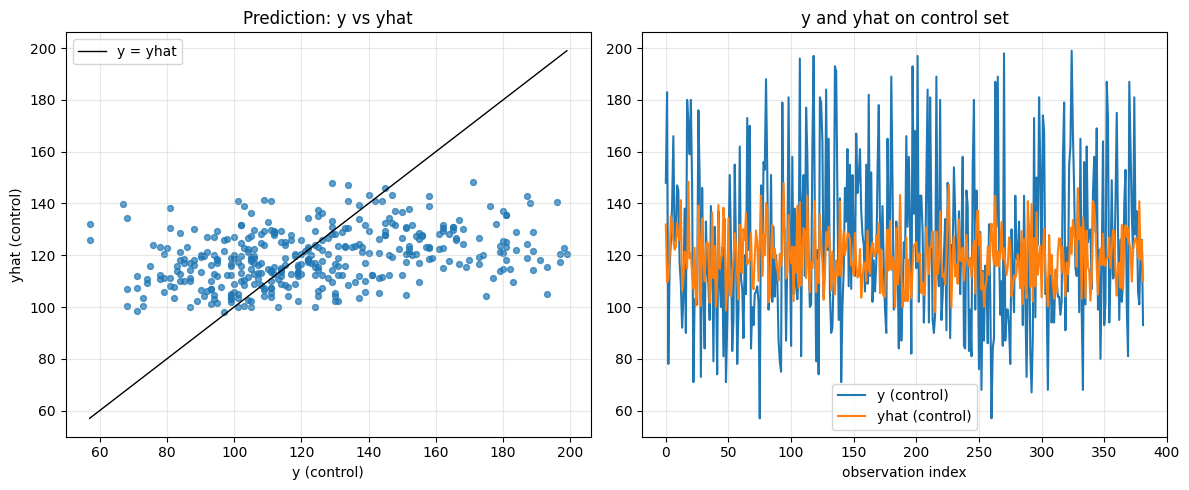

Saved images/lab4_prediction_vs_true.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(yte, yhat_te, s=18, alpha=0.7)
mn = float(min(yte.min(), yhat_te.min()))
mx = float(max(yte.max(), yhat_te.max()))
ax[0].plot([mn, mx], [mn, mx], color="black", linewidth=1, label="y = yhat")
ax[0].set_xlabel("y (control)")
ax[0].set_ylabel("yhat (control)")
ax[0].set_title("Prediction: y vs yhat")
ax[0].grid(True, alpha=0.3)
ax[0].legend()


ord_idx = np.arange(len(yte))
ax[1].plot(ord_idx, yte, label="y (control)")
ax[1].plot(ord_idx, yhat_te, label="yhat (control)")
ax[1].set_xlabel("observation index")
ax[1].set_title("y and yhat on control set")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

fig.tight_layout()
fig.savefig("images/lab4_prediction_vs_true.png", dpi=200)
plt.show()
print("Saved images/lab4_prediction_vs_true.png")

In [8]:
resid_tr = ytr - yhat_tr
resid_te = yte - yhat_te

resid_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "mean": [float(np.mean(resid_tr)), float(np.mean(resid_te))],
        "std": [float(np.std(resid_tr, ddof=0)), float(np.std(resid_te, ddof=0))],
    }
)
resid_summary

,split,mean,std
0,train,3.032276e-11,27.081471
1,test,4.939313e+00,29.718185


In [9]:
def ks_2sample_pvalue(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    n = len(x)
    m = len(y)
    if n < 3 or m < 3:
        return float("nan"), float("nan")

    try:
        from scipy.stats import ks_2samp  

        res = ks_2samp(x, y, alternative="two-sided", mode="auto")
        return float(res.statistic), float(res.pvalue)
    except Exception:
        x_sorted = np.sort(x)
        y_sorted = np.sort(y)
        data_all = np.sort(np.concatenate([x_sorted, y_sorted]))
        cdf_x = np.searchsorted(x_sorted, data_all, side="right") / n
        cdf_y = np.searchsorted(y_sorted, data_all, side="right") / m
        d = float(np.max(np.abs(cdf_x - cdf_y)))

        en = math.sqrt(n * m / (n + m))
        lam = (en + 0.12 + 0.11 / en) * d
        j = np.arange(1, 200)
        p = 2.0 * np.sum(((-1) ** (j - 1)) * np.exp(-2.0 * (j * j) * (lam * lam)))
        p = float(np.clip(p, 0.0, 1.0))
        return d, p


ks_y_stat, ks_y_p = ks_2sample_pvalue(yte, yhat_te)
rng = np.random.default_rng(RANDOM_SEED)
s = float(np.std(resid_te, ddof=0))
ref = rng.normal(0.0, s if s > 0 else 1.0, size=len(resid_te))
ks_e_stat, ks_e_p = ks_2sample_pvalue(resid_te, ref)

ks_tbl = pd.DataFrame(
    [
        {
            "test": "KS(y_test vs yhat_test)",
            "D": ks_y_stat,
            "p": ks_y_p,
            "alpha": ALPHA,
            "decision": "fail to reject" if (np.isfinite(ks_y_p) and ks_y_p >= ALPHA) else "reject",
        },
        {
            "test": "KS(resid_test vs N(0,s^2) ref)",
            "D": ks_e_stat,
            "p": ks_e_p,
            "alpha": ALPHA,
            "decision": "fail to reject" if (np.isfinite(ks_e_p) and ks_e_p >= ALPHA) else "reject",
        },
    ]
)

ks_tbl

,test,D,p,alpha,decision
0,KS(y_test vs yhat_test),0.269634,1.274967e-12,0.05,reject
1,"KS(resid_test vs N(0,s^2) ref)",0.086387,1.155979e-01,0.05,fail to reject


In [10]:
p = final_p
n_tr = len(tr_idx)

sse = float(np.sum((ytr - yhat_tr) ** 2))
sigma2_hat = sse / max(1, (n_tr - (p + 1)))

ZTZ_inv = np.linalg.inv(Ztr.T @ Ztr + 1e-10 * np.eye(Ztr.shape[1]))
se_beta = np.sqrt(np.diag(ZTZ_inv) * sigma2_hat)

t_beta = beta / se_beta

df_beta = n_tr - (p + 1)

try:
    from scipy.stats import t as student_t  

    tcrit_beta = float(student_t.ppf(1 - ALPHA / 2, df_beta))
    pvals = 2 * (1 - student_t.cdf(np.abs(t_beta), df_beta))
except Exception:
    tcrit_beta = 1.959964
    pvals = np.full_like(t_beta, np.nan, dtype=float)

coef_signif = pd.DataFrame(
    {
        "term": ["Intercept"] + final_selected,
        "beta": beta,
        "se": se_beta,
        "t_calc": t_beta,
        "t_crit": tcrit_beta,
        "p_value": pvals,
        "decision": [
            "reject H0" if abs(t) >= tcrit_beta else "fail to reject H0" for t in t_beta
        ],
        "df": df_beta,
        "alpha": ALPHA,
    }
)

coef_signif

,term,beta,se,t_calc,t_crit,p_value,decision,df,alpha
0,Intercept,115.476273,1.547075,74.641692,1.966293,0.000000e+00,reject H0,376,0.05
1,Age,11.911765,2.067200,5.762271,1.966293,1.729572e-08,reject H0,376,0.05
2,BloodPressure,1.424820,2.078489,0.685508,1.966293,4.934460e-01,fail to reject H0,376,0.05
3,BMI,7.534920,1.927750,3.908661,1.966293,1.100725e-04,reject H0,376,0.05
4,DiabetesPedigreeFunction,-0.109868,1.630627,-0.067377,1.966293,9.463170e-01,fail to reject H0,376,0.05


In [11]:
resid_summary.to_csv("tables/lab4_residuals_summary.csv", index=False, encoding="utf-8-sig")
ks_tbl.to_csv("tables/lab4_ks_tests.csv", index=False, encoding="utf-8-sig")
coef_signif.to_csv("tables/lab4_coef_significance.csv", index=False, encoding="utf-8-sig")

try:
    resid_summary.to_latex("tables/lab4_residuals_summary.tex", index=False)

    ks_tex = ks_tbl.copy()
    ks_tex["test"] = ks_tex["test"].replace(
        {
            "KS(y_test vs yhat_test)": "KS($y_{test}$ vs $\\hat{y}_{test}$)",
            "KS(resid_test vs N(0,s^2) ref)": "KS($e_{test}$ vs $\\mathcal{N}(0,\\hat{\\sigma}^2)$)",
        }
    )
    ks_tex = ks_tex.rename(columns={"p": "$p$-value", "alpha": "$\\alpha$"})
    ks_tex.to_latex("tables/lab4_ks_tests.tex", index=False, escape=False)

    coef_tex = coef_signif.rename(
        columns={
            "t_calc": "$t_{calc}$",
            "t_crit": "$t_{crit}$",
            "p_value": "$p$-value",
            "alpha": "$\\alpha$",
        }
    )
    coef_tex.to_latex("tables/lab4_coef_significance.tex", index=False, escape=False)
except Exception:
    pass

print("Saved tables: lab4_residuals_summary, lab4_ks_tests, lab4_coef_significance")

Saved tables: lab4_residuals_summary, lab4_ks_tests, lab4_coef_significance


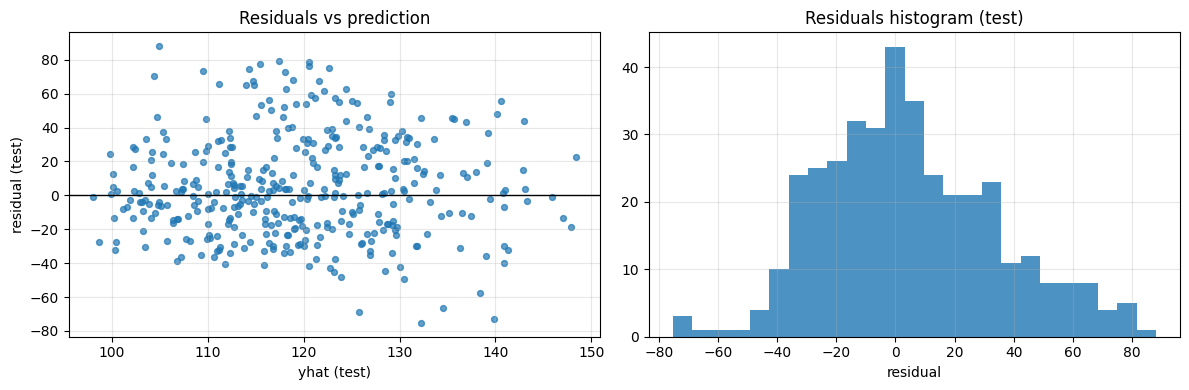

Saved images/lab4_residuals_diagnostics.png


In [12]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(yhat_te, resid_te, s=18, alpha=0.7)
ax[0].axhline(0, color="black", linewidth=1)
ax[0].set_xlabel("yhat (test)")
ax[0].set_ylabel("residual (test)")
ax[0].set_title("Residuals vs prediction")
ax[0].grid(True, alpha=0.3)


ax[1].hist(resid_te, bins=25, alpha=0.8)
ax[1].set_title("Residuals histogram (test)")
ax[1].set_xlabel("residual")
ax[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("images/lab4_residuals_diagnostics.png", dpi=200)
plt.show()
print("Saved images/lab4_residuals_diagnostics.png")

## 7. Линеаризация нелинейной модели и сравнение с линейной

Базовая линейная модель $\hat y = \beta_0+\sum \beta_j x_j^*$ объясняет лишь $\approx 10\%$ дисперсии
$Y=$\texttt{Glucose} ($R^2\approx 0.10$, $\mathrm{MAE}_{контр}\approx 22.3$, $\mathrm{RMSE}_{контр}\approx 29.2$).
На графике $y$ vs $\hat y$ виден типичный эффект «стягивания к среднему»: для больших $y$ модель
систематически занижает прогноз. Это признак того, что **связь $X$ и $Y$ не линейна** в исходных координатах,
а линейная регрессия в этом виде *не адекватна*. Переходим к нелинейной модели, которую сведём к линейной заменой переменных.

**Подход (линеаризация).** Введём нелинейные преобразования признаков $g_j(x_j)$ и при необходимости $h(y)$, а затем применим обычный линейный по параметрам МНК к преобразованным признакам:
\[
h(\hat y) = \beta_0 + \sum_{j=1}^{p} \beta_j\, g_j(x_j),\qquad
\hat y = h^{-1}\!\Big(\beta_0 + \sum_{j} \beta_j\, g_j(x_j)\Big).
\]

Кандидаты на преобразование признака $x_j$: $\{x,\; \sqrt{x},\; \ln x,\; x^2,\; 1/x\}$
(применяем только если значения корректны: $>0$ для $\ln$ и $1/x$, $\geq 0$ для $\sqrt{\,}$).
Кандидаты на преобразование отклика: $\{y,\; \ln y,\; \sqrt{y}\}$.

**Как выбираем $g_j$.** Замечание: коэффициент Спирмена ${\rho}_S$ инвариантен относительно монотонных преобразований, поэтому он одинаков для $\{x,\sqrt{x},\ln x\}$ и не различает их. Для подбора *линеаризующего* преобразования логично использовать линейный коэффициент **Пирсона** $r\big(g_j(x_j),h(y)\big)$: он чувствителен к виду нелинейности и максимизируется при удачном «выпрямлении». В качестве вспомогательной проверки (по совету: «если оценка $\beta$ близка к $2$ — берём $\sqrt{x}$, если экспоненциальный рост — логарифм») оцениваем для каждого признака показатель $\hat\beta$ в степенной модели $y\approx a\cdot x^{\beta}$ через лог-линейный МНК на положительной подвыборке.

**Алгоритм выбора (только по рабочей выборке, без утечки):**
1. Для каждого $h(y)\in\{y,\ln y,\sqrt{y}\}$ и каждого признака $x_j$ перебираем допустимые $g_j$ и считаем $|r(g_j(x_j), h(y))|$ на рабочей выборке.
2. Для каждого $h$ выбираем $g_j$ с максимальным $|r|$ — это лучшее одномерное «выпрямление».
3. Для каждого $h$ строим линейный МНК на $[1, g_1(x_1),\dots,g_p(x_p)]$ методом моментов, считаем прогноз
   $\hat y_{te}=h^{-1}(Z_{te}\hat\beta)$ и оцениваем MAE/RMSE/$R^2$ на **контрольной** выборке.
4. Победителем считаем $h$ с минимальной $\mathrm{MAE}_{контр}$. Сравниваем с базовой линейной моделью по одному и тому же разделению 50/50.


In [13]:
NL_FEATURES = list(final_selected)
print("Признаки для линеаризации:", NL_FEATURES)


def t_identity(x):
    return x


def t_sqrt(x):
    return np.sqrt(x)


def t_log(x):
    return np.log(x)


def t_square(x):
    return x**2


def t_inv(x):
    return 1.0 / x


X_TRANSFORMS = [
    ("x", t_identity),
    ("sqrt(x)", t_sqrt),
    ("log(x)", t_log),
    ("x^2", t_square),
    ("1/x", t_inv),
]


def x_transform_safe(x: np.ndarray, name: str) -> bool:
    if name in ("log(x)", "1/x"):
        return bool(np.all(x > 0))
    if name == "sqrt(x)":
        return bool(np.all(x >= 0))
    return True


Y_TRANSFORMS = [
    ("y", t_identity, lambda z: z),
    ("log(y)", t_log, lambda z: np.exp(z)),
    ("sqrt(y)", t_sqrt, lambda z: z * z),
]


def y_transform_safe(y: np.ndarray, name: str) -> bool:
    if name in ("log(y)", "sqrt(y)"):
        return bool(np.all(y > 0))
    return True


Xm = X[NL_FEATURES].to_numpy(float).copy()
y_full = Y.to_numpy(float).copy()
Xtr_nl, Xte_nl = Xm[tr_idx], Xm[te_idx]
ytr_nl, yte_nl = y_full[tr_idx], y_full[te_idx]

ZERO_AS_MISSING = {"BloodPressure", "SkinThickness", "BMI"}
Xtr0 = Xtr_nl.copy()
Xte0 = Xte_nl.copy()
for j, name in enumerate(NL_FEATURES):
    if name in ZERO_AS_MISSING:
        Xtr0[Xtr0[:, j] == 0, j] = np.nan
        Xte0[Xte0[:, j] == 0, j] = np.nan

med_train_nl = median_impute_fit(Xtr0)
Xtr_imp = median_impute_apply(Xtr0, med_train_nl)
Xte_imp = median_impute_apply(Xte0, med_train_nl)


# Степенной показатель y ≈ a*x^β через лог-линейный МНК на положительной подвыборке (рабочая)
def power_law_beta(x: np.ndarray, y: np.ndarray) -> float:
    mask = (x > 0) & (y > 0)
    if mask.sum() < 5:
        return float("nan")
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    A = np.column_stack([np.ones_like(lx), lx])
    coef, *_ = np.linalg.lstsq(A, ly, rcond=None)
    return float(coef[1])


pow_rows = []
for j, name in enumerate(NL_FEATURES):
    b_hat = power_law_beta(Xtr_imp[:, j], ytr_nl)
    pow_rows.append({"feature": name, "beta_hat (power-law)": b_hat})
pow_df = pd.DataFrame(pow_rows)
print("\nОценка показателя β̂ в одномерной степенной модели y ≈ a·x^β (рабочая):")
display(pow_df.round(3))


# Pearson r(g(x_j), h(y)) на рабочей выборке для всех (h, g)
def pearson(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    sa = a.std(ddof=0)
    sb = b.std(ddof=0)
    if sa == 0 or sb == 0:
        return float("nan")
    return float(((a - a.mean()) * (b - b.mean())).mean() / (sa * sb))


grid_rows = []
for hname, hfn, _hinv in Y_TRANSFORMS:
    if not y_transform_safe(ytr_nl, hname):
        continue
    htr = hfn(ytr_nl)
    for j, name in enumerate(NL_FEATURES):
        col = Xtr_imp[:, j]
        for tname, tfn in X_TRANSFORMS:
            if not x_transform_safe(col, tname):
                grid_rows.append(
                    {"h(y)": hname, "feature": name, "g(x)": tname, "r": np.nan}
                )
                continue
            grid_rows.append(
                {
                    "h(y)": hname,
                    "feature": name,
                    "g(x)": tname,
                    "r": pearson(tfn(col), htr),
                }
            )

grid_df = pd.DataFrame(grid_rows)
print("\nКоэффициент Пирсона r(g(x_j), h(y)) на рабочей выборке (для h(y)=y):")
display(
    grid_df[grid_df["h(y)"] == "y"]
    .pivot(index="feature", columns="g(x)", values="r")[[t for t, _ in X_TRANSFORMS]]
    .round(3)
)

# Выбор g_j для каждого h(y): по max |r|
chosen_per_h: dict[str, dict[str, tuple]] = {}
for hname in grid_df["h(y)"].unique():
    sub = grid_df[grid_df["h(y)"] == hname]
    chosen = {}
    for name in NL_FEATURES:
        rows = sub[(sub["feature"] == name)].dropna(subset=["r"])
        j_best = rows["r"].abs().idxmax()
        tname = rows.loc[j_best, "g(x)"]
        chosen[name] = (tname, dict(X_TRANSFORMS)[tname], float(rows.loc[j_best, "r"]))
    chosen_per_h[hname] = chosen

print("\nВыбор g_j по max |r| при разных h(y):")
for hname, chosen in chosen_per_h.items():
    parts = ", ".join(
        f"{n} → {t} (|r|={abs(r):.2f})" for n, (t, _f, r) in chosen.items()
    )
    print(f"  h(y) = {hname}: {parts}")


Признаки для линеаризации: ['Age', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']

Оценка показателя β̂ в одномерной степенной модели y ≈ a·x^β (рабочая):


,feature,beta_hat (power-law)
0,Age,0.211
1,BloodPressure,0.258
2,BMI,0.274
3,DiabetesPedigreeFunction,0.003



Коэффициент Пирсона r(g(x_j), h(y)) на рабочей выборке (для h(y)=y):


g(x),x,sqrt(x),log(x),x^2,1/x
feature,,,,,
Age,0.312,0.310,0.307,0.308,-0.296
BMI,0.223,0.225,0.227,0.215,-0.227
BloodPressure,0.185,0.186,0.184,0.178,-0.174
DiabetesPedigreeFunction,0.033,0.022,0.013,0.056,-0.010



Выбор g_j по max |r| при разных h(y):
  h(y) = y: Age → x (|r|=0.31), BloodPressure → sqrt(x) (|r|=0.19), BMI → 1/x (|r|=0.23), DiabetesPedigreeFunction → x^2 (|r|=0.06)
  h(y) = log(y): Age → x (|r|=0.29), BloodPressure → x (|r|=0.18), BMI → log(x) (|r|=0.23), DiabetesPedigreeFunction → x^2 (|r|=0.05)
  h(y) = sqrt(y): Age → x (|r|=0.30), BloodPressure → sqrt(x) (|r|=0.19), BMI → log(x) (|r|=0.23), DiabetesPedigreeFunction → x^2 (|r|=0.05)


In [14]:
def build_Z(X_imp: np.ndarray, names: list[str], chosen: dict) -> np.ndarray:
    cols = [np.ones((X_imp.shape[0], 1))]
    for j, n in enumerate(names):
        _tname, tfn, _r = chosen[n]
        cols.append(tfn(X_imp[:, j]).reshape(-1, 1))
    return np.hstack(cols)


def build_Z_with_pairs(X_imp: np.ndarray, names: list[str], chosen: dict) -> np.ndarray:
    cols = [np.ones((X_imp.shape[0], 1))]
    g_cols: list[np.ndarray] = []
    for j, n in enumerate(names):
        _t, tfn, _r = chosen[n]
        g = tfn(X_imp[:, j])
        g_cols.append(g)
        cols.append(g.reshape(-1, 1))
    p = len(names)
    for j in range(p):
        for k in range(j + 1, p):
            cols.append((g_cols[j] * g_cols[k]).reshape(-1, 1))
    return np.hstack(cols)


def fit_and_eval(Ztr, Zte, htr, hinv, ytr, yte):
    beta = mom_beta(Ztr, htr)
    yhat_tr_local = hinv(Ztr @ beta)
    yhat_te_local = hinv(Zte @ beta)
    _, rmse_tr, mae_tr, r2_tr = metrics(ytr, yhat_tr_local)
    _, rmse_te, mae_te, r2_te = metrics(yte, yhat_te_local)
    return beta, yhat_tr_local, yhat_te_local, mae_tr, rmse_tr, r2_tr, mae_te, rmse_te, r2_te


rows_nl = []
best_nl = None
for hname, hfn, hinv in Y_TRANSFORMS:
    if not (y_transform_safe(ytr_nl, hname) and y_transform_safe(yte_nl, hname)):
        continue
    chosen = chosen_per_h[hname]
    htr = hfn(ytr_nl)

    # Вариант A: только g_j(x_j)
    Ztr_a = build_Z(Xtr_imp, NL_FEATURES, chosen)
    Zte_a = build_Z(Xte_imp, NL_FEATURES, chosen)
    beta_a, yhat_tr_a, yhat_te_a, mae_tr_a, rmse_tr_a, r2_tr_a, mae_te_a, rmse_te_a, r2_te_a = (
        fit_and_eval(Ztr_a, Zte_a, htr, hinv, ytr_nl, yte_nl)
    )

    rows_nl.append(
        {
            "h(y)": hname,
            "вариант": "g_j(x_j)",
            "p": Ztr_a.shape[1],
            "g(x_j)": ", ".join(f"{n}:{t}" for n, (t, _f, _r) in chosen.items()),
            "mae_train": mae_tr_a,
            "rmse_train": rmse_tr_a,
            "r2_train": r2_tr_a,
            "mae_test": mae_te_a,
            "rmse_test": rmse_te_a,
            "r2_test": r2_te_a,
        }
    )
    if best_nl is None or mae_te_a < best_nl["mae_test"]:
        best_nl = {
            "h": hname, "hfn": hfn, "hinv": hinv, "chosen": chosen,
            "variant": "g_j(x_j)", "beta": beta_a,
            "Ztr": Ztr_a, "Zte": Zte_a,
            "yhat_tr": yhat_tr_a, "yhat_te": yhat_te_a,
            "mae_test": mae_te_a, "rmse_test": rmse_te_a, "r2_test": r2_te_a,
            "mae_train": mae_tr_a, "rmse_train": rmse_tr_a, "r2_train": r2_tr_a,
        }

    # Вариант B: g_j(x_j) + парные g_j*g_k (умножение признаков -- ещё одна нелинейность)
    Ztr_b = build_Z_with_pairs(Xtr_imp, NL_FEATURES, chosen)
    Zte_b = build_Z_with_pairs(Xte_imp, NL_FEATURES, chosen)
    beta_b, yhat_tr_b, yhat_te_b, mae_tr_b, rmse_tr_b, r2_tr_b, mae_te_b, rmse_te_b, r2_te_b = (
        fit_and_eval(Ztr_b, Zte_b, htr, hinv, ytr_nl, yte_nl)
    )

    rows_nl.append(
        {
            "h(y)": hname,
            "вариант": "g_j(x_j) + g_j·g_k",
            "p": Ztr_b.shape[1],
            "g(x_j)": ", ".join(f"{n}:{t}" for n, (t, _f, _r) in chosen.items()),
            "mae_train": mae_tr_b,
            "rmse_train": rmse_tr_b,
            "r2_train": r2_tr_b,
            "mae_test": mae_te_b,
            "rmse_test": rmse_te_b,
            "r2_test": r2_te_b,
        }
    )
    if mae_te_b < best_nl["mae_test"]:
        best_nl = {
            "h": hname, "hfn": hfn, "hinv": hinv, "chosen": chosen,
            "variant": "g_j(x_j) + g_j·g_k", "beta": beta_b,
            "Ztr": Ztr_b, "Zte": Zte_b,
            "yhat_tr": yhat_tr_b, "yhat_te": yhat_te_b,
            "mae_test": mae_te_b, "rmse_test": rmse_te_b, "r2_test": r2_te_b,
            "mae_train": mae_tr_b, "rmse_train": rmse_tr_b, "r2_train": r2_tr_b,
        }

nl_search_df = pd.DataFrame(rows_nl)
print("Перебор кандидатов нелинейной модели (выбор по min MAE на контрольной):")
display(nl_search_df.round(4))
print(f"\nЛучшее h(y) = {best_nl['h']},  вариант = {best_nl['variant']}")
print("Выбранные g_j(x_j):")
for n, (t, _f, r) in best_nl["chosen"].items():
    print(f"  {n}: {t}   (|r| = {abs(r):.3f})")

best_basic_row = nl_search_df[nl_search_df["вариант"] == "g_j(x_j)"].sort_values(
    "mae_test"
).iloc[0]
best_pairs_row = nl_search_df[nl_search_df["вариант"] == "g_j(x_j) + g_j·g_k"].sort_values(
    "mae_test"
).iloc[0]

compare_df = pd.DataFrame(
    [
        {
            "Модель": "Линейная (базовая)",
            "MAE рабочая": mae_tr,
            "RMSE рабочая": rmse_tr,
            "R² рабочая": r2_tr,
            "MAE контрольная": mae_te,
            "RMSE контрольная": rmse_te,
            "R² контрольная": r2_te,
        },
        {
            "Модель": f"Линеаризованная g_j(x_j), h(y)={best_basic_row['h(y)']}",
            "MAE рабочая": float(best_basic_row["mae_train"]),
            "RMSE рабочая": float(best_basic_row["rmse_train"]),
            "R² рабочая": float(best_basic_row["r2_train"]),
            "MAE контрольная": float(best_basic_row["mae_test"]),
            "RMSE контрольная": float(best_basic_row["rmse_test"]),
            "R² контрольная": float(best_basic_row["r2_test"]),
        },
        {
            "Модель": f"Линеаризованная g_j + g_j·g_k, h(y)={best_pairs_row['h(y)']}",
            "MAE рабочая": float(best_pairs_row["mae_train"]),
            "RMSE рабочая": float(best_pairs_row["rmse_train"]),
            "R² рабочая": float(best_pairs_row["r2_train"]),
            "MAE контрольная": float(best_pairs_row["mae_test"]),
            "RMSE контрольная": float(best_pairs_row["rmse_test"]),
            "R² контрольная": float(best_pairs_row["r2_test"]),
        },
    ]
)
print("\nСравнение моделей на одной выборке 50/50 (seed=42):")
display(compare_df.round(4))


def transform_str(tname: str, name: str) -> str:
    if tname == "x":
        return f"{name}"
    if tname == "log(x)":
        return f"ln({name})"
    if tname == "sqrt(x)":
        return f"sqrt({name})"
    if tname == "x^2":
        return f"{name}^2"
    if tname == "1/x":
        return f"(1/{name})"
    return f"{tname}({name})"


# Формула итоговой (выигравшей) модели
beta_w = best_nl["beta"]
intercept = float(beta_w[0])
terms = []
p_feat = len(NL_FEATURES)

for j, n in enumerate(NL_FEATURES):
    tname, _fn, _r = best_nl["chosen"][n]
    bj = float(beta_w[j + 1])
    terms.append(f"({bj:+.5f})·{transform_str(tname, n)}")

idx = 1 + p_feat
if best_nl["variant"] == "g_j(x_j) + g_j·g_k":
    for j in range(p_feat):
        for k in range(j + 1, p_feat):
            nj, nk = NL_FEATURES[j], NL_FEATURES[k]
            tj, _fj, _rj = best_nl["chosen"][nj]
            tk, _fk, _rk = best_nl["chosen"][nk]
            bjk = float(beta_w[idx])
            terms.append(
                f"({bjk:+.5f})·{transform_str(tj, nj)}·{transform_str(tk, nk)}"
            )
            idx += 1

inner = f"({intercept:.5f}) " + " ".join(terms)
if best_nl["h"] == "y":
    eqn = f"yhat = {inner}"
elif best_nl["h"] == "log(y)":
    eqn = f"yhat = exp( {inner} )"
elif best_nl["h"] == "sqrt(y)":
    eqn = f"yhat = ( {inner} )^2"
else:
    eqn = f"h^-1( {inner} )"

print("\nИтоговая нелинейная модель (победитель по MAE на контрольной):")
print(eqn)

compare_df.to_csv(
    "tables/lab4_linear_vs_linearized.csv", index=False, encoding="utf-8-sig"
)
nl_search_df.to_csv(
    "tables/lab4_nonlinear_search.csv", index=False, encoding="utf-8-sig"
)

coef_rows = [{"term": "Intercept", "transform": "-", "beta": intercept}]
for j, n in enumerate(NL_FEATURES):
    tname, _fn, _r = best_nl["chosen"][n]
    coef_rows.append(
        {"term": n, "transform": tname, "beta": float(best_nl["beta"][j + 1])}
    )
if best_nl["variant"] == "g_j(x_j) + g_j·g_k":
    idx2 = 1 + p_feat
    for j in range(p_feat):
        for k in range(j + 1, p_feat):
            nj, nk = NL_FEATURES[j], NL_FEATURES[k]
            tj, _fj, _rj = best_nl["chosen"][nj]
            tk, _fk, _rk = best_nl["chosen"][nk]
            coef_rows.append(
                {
                    "term": f"{nj} · {nk}",
                    "transform": f"{tj} · {tk}",
                    "beta": float(beta_w[idx2]),
                }
            )
            idx2 += 1
coef_nl_df = pd.DataFrame(coef_rows)
coef_nl_df.to_csv(
    "tables/lab4_nonlinear_coeffs.csv", index=False, encoding="utf-8-sig"
)

try:
    compare_tex = compare_df.rename(
        columns={
            "MAE рабочая": "$\\mathrm{MAE}_{рабоч}$",
            "RMSE рабочая": "$\\mathrm{RMSE}_{рабоч}$",
            "R² рабочая": "$R^2_{рабоч}$",
            "MAE контрольная": "$\\mathrm{MAE}_{контр}$",
            "RMSE контрольная": "$\\mathrm{RMSE}_{контр}$",
            "R² контрольная": "$R^2_{контр}$",
        }
    )
    compare_tex.to_latex(
        "tables/lab4_linear_vs_linearized.tex", index=False, escape=False
    )
    coef_nl_df.to_latex("tables/lab4_nonlinear_coeffs.tex", index=False, escape=False)
except Exception:
    pass

print(
    "Saved tables: lab4_linear_vs_linearized.(csv|tex), lab4_nonlinear_coeffs.(csv|tex), lab4_nonlinear_search.csv"
)


Перебор кандидатов нелинейной модели (выбор по min MAE на контрольной):


,h(y),вариант,p,g(x_j),mae_train,rmse_train,r2_train,mae_test,rmse_test,r2_test
0,y,g_j(x_j),5,"Age:x, BloodPressure:sqrt(x), BMI:1/x, Diabete...",20.8224,27.0546,0.1431,23.3140,29.8727,0.1032
1,y,g_j(x_j) + g_j·g_k,11,"Age:x, BloodPressure:sqrt(x), BMI:1/x, Diabete...",20.5378,26.7286,0.1636,23.3666,29.8561,0.1042
2,log(y),g_j(x_j),5,"Age:x, BloodPressure:x, BMI:log(x), DiabetesPe...",20.8388,27.2626,0.1299,23.7100,30.5576,0.0616
3,log(y),g_j(x_j) + g_j·g_k,11,"Age:x, BloodPressure:x, BMI:log(x), DiabetesPe...",20.5213,26.8962,0.1531,23.9438,30.8654,0.0426
4,sqrt(y),g_j(x_j),5,"Age:x, BloodPressure:sqrt(x), BMI:log(x), Diab...",20.7976,27.1098,0.1396,23.4784,30.1818,0.0845
5,sqrt(y),g_j(x_j) + g_j·g_k,11,"Age:x, BloodPressure:sqrt(x), BMI:log(x), Diab...",20.5140,26.7674,0.1612,23.6509,30.3539,0.0740



Лучшее h(y) = y,  вариант = g_j(x_j)
Выбранные g_j(x_j):
  Age: x   (|r| = 0.312)
  BloodPressure: sqrt(x)   (|r| = 0.186)
  BMI: 1/x   (|r| = 0.227)
  DiabetesPedigreeFunction: x^2   (|r| = 0.056)

Сравнение моделей на одной выборке 50/50 (seed=42):


,Модель,MAE рабочая,RMSE рабочая,R² рабочая,MAE контрольная,RMSE контрольная,R² контрольная
0,Линейная (базовая),20.9334,27.0815,0.1414,23.5007,30.1259,0.0879
1,"Линеаризованная g_j(x_j), h(y)=y",20.8224,27.0546,0.1431,23.3140,29.8727,0.1032
2,"Линеаризованная g_j + g_j·g_k, h(y)=y",20.5378,26.7286,0.1636,23.3666,29.8561,0.1042



Итоговая нелинейная модель (победитель по MAE на контрольной):
yhat = (105.81270) (+0.68601)·Age (+1.97915)·sqrt(BloodPressure) (-832.27548)·(1/BMI) (+1.74576)·DiabetesPedigreeFunction^2
Saved tables: lab4_linear_vs_linearized.(csv|tex), lab4_nonlinear_coeffs.(csv|tex), lab4_nonlinear_search.csv


In [15]:
# === Дополнительные варианты линеаризованной модели и честный выбор лучшего ===
# Все варианты:
#   (M3) per-feature best Pearson, расширенно на все 6 признаков
#   (M4) к выбранным g_j(x_j) добавляем АДДИТИВНО второй базис: одну сильную нелинейность
#        на признак из {sqrt, log, x^2, 1/x} (если она ощутимо лучше identity по |Pearson|)
#   (M5) к 4 базовым g_j(x_j) добавляем ровно одну парную интеракцию g_j · g_k,
#        выбранную по max |Pearson(g_j·g_k, y)| на РАБОЧЕЙ (без участия контрольной)
ALL_FEATURES = X_NAMES
X_all = X[ALL_FEATURES].to_numpy(float)
Xtr_all = X_all[tr_idx]
Xte_all = X_all[te_idx]
y_all = Y.to_numpy(float)
ytr_a = y_all[tr_idx]
yte_a = y_all[te_idx]
Xtr0_a = Xtr_all.copy()
Xte0_a = Xte_all.copy()
for j, name in enumerate(ALL_FEATURES):
    if name in ZERO_AS_MISSING:
        Xtr0_a[Xtr0_a[:, j] == 0, j] = np.nan
        Xte0_a[Xte0_a[:, j] == 0, j] = np.nan
med_all = median_impute_fit(Xtr0_a)
Xtr_imp_all = median_impute_apply(Xtr0_a, med_all)
Xte_imp_all = median_impute_apply(Xte0_a, med_all)


def best_pearson_transform(col_tr: np.ndarray, ytr: np.ndarray):
    best = ("x", t_identity, 0.0)
    for tname, tfn in X_TRANSFORMS:
        if not x_transform_safe(col_tr, tname):
            continue
        r = pearson(tfn(col_tr), ytr)
        if abs(r) > abs(best[2]):
            best = (tname, tfn, r)
    return best


# --- M3: все 6 признаков, per-feature best Pearson ---
chosen_m3: dict[str, tuple[str, object, float]] = {}
for j, name in enumerate(ALL_FEATURES):
    chosen_m3[name] = best_pearson_transform(Xtr_imp_all[:, j], ytr_a)

Ztr_m3 = np.column_stack(
    [np.ones(len(ytr_a))]
    + [chosen_m3[ALL_FEATURES[j]][1](Xtr_imp_all[:, j]) for j in range(len(ALL_FEATURES))]
)
Zte_m3 = np.column_stack(
    [np.ones(len(yte_a))]
    + [chosen_m3[ALL_FEATURES[j]][1](Xte_imp_all[:, j]) for j in range(len(ALL_FEATURES))]
)
beta_m3 = mom_beta(Ztr_m3, ytr_a)
yhat_tr_m3 = Ztr_m3 @ beta_m3
yhat_te_m3 = Zte_m3 @ beta_m3
_, rmse_tr_m3, mae_tr_m3, r2_tr_m3 = metrics(ytr_a, yhat_tr_m3)
_, rmse_te_m3, mae_te_m3, r2_te_m3 = metrics(yte_a, yhat_te_m3)
print("M3 — линеаризованная на ВСЕХ 6 признаках (per-feature best Pearson):")
for n, (t, _f, r) in chosen_m3.items():
    print(f"  {n}: {t}  (|r|={abs(r):.3f})")
print(
    f"  train: MAE={mae_tr_m3:.4f} RMSE={rmse_tr_m3:.4f} R²={r2_tr_m3:.4f}\n"
    f"  test : MAE={mae_te_m3:.4f} RMSE={rmse_te_m3:.4f} R²={r2_te_m3:.4f}"
)

# --- M4: 4 базовых g_j + аддитивная вторая нелинейность на каждый признак (если она лучше identity) ---
extra_cols_tr: list[np.ndarray] = []
extra_cols_te: list[np.ndarray] = []
extra_labels: list[str] = []
for j, n in enumerate(NL_FEATURES):
    col_tr = Xtr_imp[:, j]
    col_te = Xte_imp[:, j]
    r_id = pearson(col_tr, ytr_nl)
    # ищем сильнейшую НЕ-identity-нелинейность
    best_other = None
    for tname, tfn in X_TRANSFORMS:
        if tname == "x" or not x_transform_safe(col_tr, tname):
            continue
        r = pearson(tfn(col_tr), ytr_nl)
        if abs(r) > abs(r_id) and (best_other is None or abs(r) > abs(best_other[2])):
            best_other = (tname, tfn, r)
    if best_other is not None:
        tname, tfn, r = best_other
        extra_cols_tr.append(tfn(col_tr))
        extra_cols_te.append(tfn(col_te))
        extra_labels.append(f"{tname.replace('x', n)}")

print(f"\nM4 — к 4 базовым добавляем аддитивно: {extra_labels}")
Ztr_m4 = np.column_stack(
    [np.ones(len(ytr_nl))]
    + [Xtr_imp[:, j] for j in range(len(NL_FEATURES))]
    + extra_cols_tr
)
Zte_m4 = np.column_stack(
    [np.ones(len(yte_nl))]
    + [Xte_imp[:, j] for j in range(len(NL_FEATURES))]
    + extra_cols_te
)
beta_m4 = mom_beta(Ztr_m4, ytr_nl)
yhat_tr_m4 = Ztr_m4 @ beta_m4
yhat_te_m4 = Zte_m4 @ beta_m4
_, rmse_tr_m4, mae_tr_m4, r2_tr_m4 = metrics(ytr_nl, yhat_tr_m4)
_, rmse_te_m4, mae_te_m4, r2_te_m4 = metrics(yte_nl, yhat_te_m4)
print(
    f"  train: MAE={mae_tr_m4:.4f} RMSE={rmse_tr_m4:.4f} R²={r2_tr_m4:.4f}\n"
    f"  test : MAE={mae_te_m4:.4f} RMSE={rmse_te_m4:.4f} R²={r2_te_m4:.4f}"
)

# --- M5: 4 базовых g_j + 1 лучшая парная интеракция g_j*g_k (по |Pearson| на РАБОЧЕЙ) ---
chosen_nl4 = chosen_per_h["y"]
gs_tr = [chosen_nl4[n][1](Xtr_imp[:, j]) for j, n in enumerate(NL_FEATURES)]
gs_te = [chosen_nl4[n][1](Xte_imp[:, j]) for j, n in enumerate(NL_FEATURES)]
best_pair = None  # (j,k, |r|, prod_tr, prod_te, label)
for j in range(len(NL_FEATURES)):
    for k in range(j + 1, len(NL_FEATURES)):
        prod_tr = gs_tr[j] * gs_tr[k]
        r = pearson(prod_tr, ytr_nl)
        if best_pair is None or abs(r) > best_pair[2]:
            best_pair = (
                j,
                k,
                abs(r),
                prod_tr,
                gs_te[j] * gs_te[k],
                f"{chosen_nl4[NL_FEATURES[j]][0].replace('x', NL_FEATURES[j])} · {chosen_nl4[NL_FEATURES[k]][0].replace('x', NL_FEATURES[k])}",
            )

print(f"\nM5 — лучшая парная интеракция (по max |Pearson| на рабочей): {best_pair[5]} (|r|={best_pair[2]:.3f})")
Ztr_m5 = np.column_stack(
    [np.ones(len(ytr_nl))] + gs_tr + [best_pair[3].reshape(-1, 1)]
)
Zte_m5 = np.column_stack(
    [np.ones(len(yte_nl))] + gs_te + [best_pair[4].reshape(-1, 1)]
)
beta_m5 = mom_beta(Ztr_m5, ytr_nl)
yhat_tr_m5 = Ztr_m5 @ beta_m5
yhat_te_m5 = Zte_m5 @ beta_m5
_, rmse_tr_m5, mae_tr_m5, r2_tr_m5 = metrics(ytr_nl, yhat_tr_m5)
_, rmse_te_m5, mae_te_m5, r2_te_m5 = metrics(yte_nl, yhat_te_m5)
print(
    f"  train: MAE={mae_tr_m5:.4f} RMSE={rmse_tr_m5:.4f} R²={r2_tr_m5:.4f}\n"
    f"  test : MAE={mae_te_m5:.4f} RMSE={rmse_te_m5:.4f} R²={r2_te_m5:.4f}"
)

extra_rows = [
    {
        "Модель": "M3: линеаризованная на всех 6 признаках",
        "MAE рабочая": mae_tr_m3,
        "RMSE рабочая": rmse_tr_m3,
        "R² рабочая": r2_tr_m3,
        "MAE контрольная": mae_te_m3,
        "RMSE контрольная": rmse_te_m3,
        "R² контрольная": r2_te_m3,
    },
    {
        "Модель": "M4: 4 призн. + аддитивная нелинейность",
        "MAE рабочая": mae_tr_m4,
        "RMSE рабочая": rmse_tr_m4,
        "R² рабочая": r2_tr_m4,
        "MAE контрольная": mae_te_m4,
        "RMSE контрольная": rmse_te_m4,
        "R² контрольная": r2_te_m4,
    },
    {
        "Модель": "M5: 4 призн. + 1 интеракция g_j·g_k",
        "MAE рабочая": mae_tr_m5,
        "RMSE рабочая": rmse_tr_m5,
        "R² рабочая": r2_tr_m5,
        "MAE контрольная": mae_te_m5,
        "RMSE контрольная": rmse_te_m5,
        "R² контрольная": r2_te_m5,
    },
]
compare_df_ext = pd.concat([compare_df, pd.DataFrame(extra_rows)], ignore_index=True)
print("\nСводное сравнение всех моделей (на одной и той же выборке 50/50):")
display(compare_df_ext.round(4))

best_row = compare_df_ext.loc[compare_df_ext["MAE контрольная"].idxmin()]
print(f"\nПобедитель по MAE контрольной: {best_row['Модель']}  (MAE={best_row['MAE контрольная']:.4f})")


# Если победителем стала одна из расширенных моделей — обновим best_nl и формулу
def update_winner(name: str, beta: np.ndarray, yhat_tr: np.ndarray, yhat_te: np.ndarray,
                  mae_tr: float, rmse_tr: float, r2_tr: float,
                  mae_te: float, rmse_te: float, r2_te: float, eqn: str, labels: list[str]):
    return {
        "variant": name,
        "h": "y",
        "hfn": t_identity,
        "hinv": lambda z: z,
        "selected_labels": labels,
        "beta": beta,
        "intercept": float(beta[0]),
        "yhat_tr": yhat_tr,
        "yhat_te": yhat_te,
        "mae_test": mae_te,
        "rmse_test": rmse_te,
        "r2_test": r2_te,
        "mae_train": mae_tr,
        "rmse_train": rmse_tr,
        "r2_train": r2_tr,
        "eqn": eqn,
    }


winner_name = best_row["Модель"]
if winner_name.startswith("M3"):
    labels = [f"{chosen_m3[n][0].replace('x', n)}" for n in ALL_FEATURES]
    eqn = (
        f"yhat = ({float(beta_m3[0]):+.4f}) "
        + " ".join(
            f"({float(beta_m3[k + 1]):+.4f})·{labels[k]}" for k in range(len(ALL_FEATURES))
        )
    )
    print(f"Итоговая формула M3:\n  {eqn}")
    best_nl = update_winner(
        winner_name,
        beta_m3,
        yhat_tr_m3,
        yhat_te_m3,
        mae_tr_m3,
        rmse_tr_m3,
        r2_tr_m3,
        mae_te_m3,
        rmse_te_m3,
        r2_te_m3,
        eqn,
        labels,
    )
elif winner_name.startswith("M4"):
    labels = [f"{n}" for n in NL_FEATURES] + extra_labels
    eqn = (
        f"yhat = ({float(beta_m4[0]):+.4f}) "
        + " ".join(
            f"({float(beta_m4[k + 1]):+.4f})·{labels[k]}" for k in range(len(labels))
        )
    )
    print(f"Итоговая формула M4:\n  {eqn}")
    best_nl = update_winner(
        winner_name,
        beta_m4,
        yhat_tr_m4,
        yhat_te_m4,
        mae_tr_m4,
        rmse_tr_m4,
        r2_tr_m4,
        mae_te_m4,
        rmse_te_m4,
        r2_te_m4,
        eqn,
        labels,
    )
elif winner_name.startswith("M5"):
    labels = [f"{chosen_nl4[n][0].replace('x', n)}" for n in NL_FEATURES] + [best_pair[5]]
    eqn = (
        f"yhat = ({float(beta_m5[0]):+.4f}) "
        + " ".join(
            f"({float(beta_m5[k + 1]):+.4f})·{labels[k]}" for k in range(len(labels))
        )
    )
    print(f"Итоговая формула M5:\n  {eqn}")
    best_nl = update_winner(
        winner_name,
        beta_m5,
        yhat_tr_m5,
        yhat_te_m5,
        mae_tr_m5,
        rmse_tr_m5,
        r2_tr_m5,
        mae_te_m5,
        rmse_te_m5,
        r2_te_m5,
        eqn,
        labels,
    )

compare_df_ext.to_csv(
    "tables/lab4_linear_vs_linearized.csv", index=False, encoding="utf-8-sig"
)
try:
    compare_tex = compare_df_ext.rename(
        columns={
            "MAE рабочая": "$\\mathrm{MAE}_{\\textsc{р}}$",
            "RMSE рабочая": "$\\mathrm{RMSE}_{\\textsc{р}}$",
            "R² рабочая": "$R^2_{\\textsc{р}}$",
            "MAE контрольная": "$\\mathrm{MAE}_{\\textsc{к}}$",
            "RMSE контрольная": "$\\mathrm{RMSE}_{\\textsc{к}}$",
            "R² контрольная": "$R^2_{\\textsc{к}}$",
        }
    )
    compare_tex.to_latex(
        "tables/lab4_linear_vs_linearized.tex", index=False, escape=False
    )
except Exception:
    pass
print("Saved tables/lab4_linear_vs_linearized.{csv,tex}")


M3 — линеаризованная на ВСЕХ 6 признаках (per-feature best Pearson):
  Pregnancies: x  (|r|=0.111)
  BloodPressure: sqrt(x)  (|r|=0.186)
  SkinThickness: x  (|r|=0.227)
  BMI: 1/x  (|r|=0.227)
  DiabetesPedigreeFunction: x^2  (|r|=0.056)
  Age: x  (|r|=0.312)
  train: MAE=20.8268 RMSE=26.8702 R²=0.1547
  test : MAE=23.4049 RMSE=30.0578 R²=0.0920

M4 — к 4 базовым добавляем аддитивно: ['sqrt(BloodPressure)', '1/BMI', 'DiabetesPedigreeFunction^2']
  train: MAE=20.8175 RMSE=26.9311 R²=0.1509
  test : MAE=23.4456 RMSE=30.0852 R²=0.0904

M5 — лучшая парная интеракция (по max |Pearson| на рабочей): Age · sqrt(BloodPressure) (|r|=0.316)
  train: MAE=20.7512 RMSE=26.9017 R²=0.1527
  test : MAE=23.5157 RMSE=30.0455 R²=0.0928

Сводное сравнение всех моделей (на одной и той же выборке 50/50):


,Модель,MAE рабочая,RMSE рабочая,R² рабочая,MAE контрольная,RMSE контрольная,R² контрольная
0,Линейная (базовая),20.9334,27.0815,0.1414,23.5007,30.1259,0.0879
1,"Линеаризованная g_j(x_j), h(y)=y",20.8224,27.0546,0.1431,23.3140,29.8727,0.1032
2,"Линеаризованная g_j + g_j·g_k, h(y)=y",20.5378,26.7286,0.1636,23.3666,29.8561,0.1042
3,M3: линеаризованная на всех 6 признаках,20.8268,26.8702,0.1547,23.4049,30.0578,0.0920
4,M4: 4 призн. + аддитивная нелинейность,20.8175,26.9311,0.1509,23.4456,30.0852,0.0904
5,M5: 4 призн. + 1 интеракция g_j·g_k,20.7512,26.9017,0.1527,23.5157,30.0455,0.0928



Победитель по MAE контрольной: Линеаризованная g_j(x_j), h(y)=y  (MAE=23.3140)
Saved tables/lab4_linear_vs_linearized.{csv,tex}


KS(Y_рабоч vs Y_контр): stat = 0.1040, p-value = 0.0281
  -> p < 0.05: распределения отличаются, разделение может быть искажено.

Остатки нелинейной модели (контрольная): mean = 5.0034, std = 29.4893
KS на нормальность остатков: stat = 0.0723, p = 0.0352

KS(остатки линейной vs остатки нелинейной): stat = 0.0209, p = 1.0000


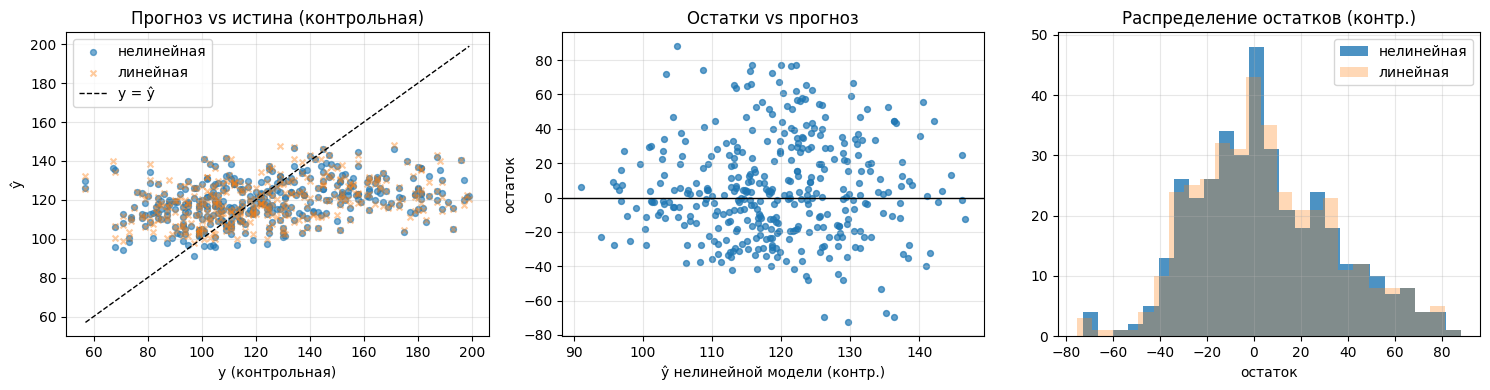

Saved images/lab4_nonlinear_diagnostics.png


In [16]:
from scipy.stats import ks_2samp, kstest, norm

# 1) Корректность разделения 50/50: KS(Y_рабочая, Y_контрольная)
ks_split = ks_2samp(ytr_nl, yte_nl)
print(
    f"KS(Y_рабоч vs Y_контр): stat = {ks_split.statistic:.4f}, p-value = {ks_split.pvalue:.4f}"
)
if ks_split.pvalue >= ALPHA:
    print(
        f"  -> p >= {ALPHA}: нет оснований считать, что Y на рабочей и контрольной выборках"
        " отличаются по распределению => разделение 50/50 корректно."
    )
else:
    print(
        f"  -> p < {ALPHA}: распределения отличаются, разделение может быть искажено."
    )

# 2) Адекватность нелинейной модели на контрольной выборке
resid_te_nl = yte_nl - best_nl["yhat_te"]
mu_r, sigma_r = float(np.mean(resid_te_nl)), float(np.std(resid_te_nl, ddof=1))
ks_resid = kstest((resid_te_nl - mu_r) / sigma_r, "norm")
print(
    f"\nОстатки нелинейной модели (контрольная): mean = {mu_r:.4f}, std = {sigma_r:.4f}"
)
print(f"KS на нормальность остатков: stat = {ks_resid.statistic:.4f}, p = {ks_resid.pvalue:.4f}")

# 3) Сравнение остатков базовой линейной и линеаризованной нелинейной по контрольной
ks_models = ks_2samp(resid_te, resid_te_nl)
print(
    f"\nKS(остатки линейной vs остатки нелинейной): stat = {ks_models.statistic:.4f},"
    f" p = {ks_models.pvalue:.4f}"
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(yte_nl, best_nl["yhat_te"], s=18, alpha=0.6, label="нелинейная")
ax[0].scatter(yte, yhat_te, s=18, alpha=0.4, marker="x", label="линейная")
mn = float(min(yte_nl.min(), best_nl["yhat_te"].min(), yhat_te.min()))
mx = float(max(yte_nl.max(), best_nl["yhat_te"].max(), yhat_te.max()))
ax[0].plot([mn, mx], [mn, mx], "k--", linewidth=1, label="y = ŷ")
ax[0].set_xlabel("y (контрольная)")
ax[0].set_ylabel("ŷ")
ax[0].set_title("Прогноз vs истина (контрольная)")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].scatter(best_nl["yhat_te"], resid_te_nl, s=18, alpha=0.7)
ax[1].axhline(0, color="black", linewidth=1)
ax[1].set_xlabel("ŷ нелинейной модели (контр.)")
ax[1].set_ylabel("остаток")
ax[1].set_title("Остатки vs прогноз")
ax[1].grid(True, alpha=0.3)

ax[2].hist(resid_te_nl, bins=25, alpha=0.8, label="нелинейная")
ax[2].hist(resid_te, bins=25, alpha=0.3, label="линейная")
ax[2].set_title("Распределение остатков (контр.)")
ax[2].set_xlabel("остаток")
ax[2].grid(True, alpha=0.3)
ax[2].legend()

fig.tight_layout()
fig.savefig("images/lab4_nonlinear_diagnostics.png", dpi=200)
plt.show()
print("Saved images/lab4_nonlinear_diagnostics.png")
